# The New-Year Pop — a quantitative teardown 🔬
### Two real pairs · HAC *t* on the January dummy · Wilson hit-rate · the decay test

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decayed since 1983?: Not supported](https://img.shields.io/badge/Decayed_since_1983%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether January's small-minus-large spread is significantly higher than the rest of the year, on a price-only long sample and a total-return tradable pair, and why the famous post-publication decay can't be measured on data that starts in 1990.

> ⚠️ **Not investment advice.** ^RUT/^GSPC are **price-only** (Yahoo has no dividends for these indices); IWM/SPY are **total-return** (`quantlab.data`). Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (new_year_pop/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from new_year_pop import data, strategy

AS_OF = "2026-06-13"
long = data.load_real_long("^RUT", "^GSPC").loc[:AS_OF]
trad = data.load_real_tradable("IWM", "SPY").loc[:AS_OF]
cL, cT = strategy.contrast(long), strategy.contrast(trad)
print(f"^RUT vs ^GSPC (price-only): {len(long)} months  {long.index[0].date()} -> {long.index[-1].date()}  fp={data.fingerprint(long)}")
print(f"IWM vs SPY  (total-return): {len(trad)} months  {trad.index[0].date()} -> {trad.index[-1].date()}  fp={data.fingerprint(trad)}")
print(f"Jan-minus-rest contrast: long {cL['diff']*100:+.2f} pts (HAC t {cL['t_contrast']:+.2f}) | tradable {cT['diff']*100:+.2f} pts (HAC t {cT['t_contrast']:+.2f})")


^RUT vs ^GSPC (price-only): 436 months  1990-02-28 -> 2026-05-31  fp=4d6121368a41
IWM vs SPY  (total-return): 312 months  2000-06-30 -> 2026-05-31  fp=2766e4b2c3b1
Jan-minus-rest contrast: long +0.18 pts (HAC t +0.31) | tradable +0.07 pts (HAC t +0.12)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | `NONE` | Jan-minus-rest contrast **+0.18 pts** (HAC *t* **+0.31**) long, **+0.07 pts** (*t* **+0.12**) tradable — both \|t\| < 2. Hit-rate 16/36 (44%, Wilson95 [30%, 60%]). |
| **Tradability** | `MIRAGE` | Seasonal timer 8.93%/yr vs 9.02% large-cap buy-and-hold; Sharpe 0.593 vs 0.619 on the tradable pair. |
| **Decayed since 1983?** | `NOT SUPPORTED` | Strong era predates Yahoo's 1990 start; pre/post-2000 difference -0.22 pts (Welch *t* -0.13), no power. |

> 💡 **In plain words:** a textbook anomaly that was real in the 1970s and is statistically invisible on every tape we can pull.

## 1 · The claim, steelmanned

- **H₁ (seasonal):** January's small-minus-large spread is higher than the other eleven months by more than noise.
- **H₂ (base-rate):** small beats large in January more often than a coin.
- **H₃ (tradable):** tilting to small for January beats buy-and-hold of the large-cap index, net of costs.

Keim (1983) and Reinganum (1983) established all three on 1960s–1970s data. We test whether any survive on 1990+ data.

## 2 · So what?

A persistent calendar edge would be a free lunch — buy small at the turn of the year, every year. Watching it evaporate is a clean case study in post-publication anomaly decay (Schwert 2003).

## 3 · How we'd know — the protocol

HAC *t* on a regression of the monthly spread on a January dummy (= the January-minus-rest mean difference) · Wilson interval on the January hit-rate · Welch test of the pre/post-2000 difference in January spread (the decay) · a seasonal timer vs buy-and-hold of each leg for tradability.

## 4 · The teardown

The January-vs-rest contrast on both pairs, with HAC inference:

In [2]:
rows = []
for lab, fr, c in [('^RUT/^GSPC (price-only)', long, cL), ('IWM/SPY (total-return)', trad, cT)]:
    rows.append({'pair': lab, 'Jan %/mo': c['jan_mean']*100, 'Rest %/mo': c['rest_mean']*100,
                 'Contrast pts': c['diff']*100, 'HAC t': c['t_contrast'],
                 'Jan hit %': c['jan_hit_rate']*100, 'Wilson lo': c['wilson_lo']*100, 'Wilson hi': c['wilson_hi']*100})
pd.DataFrame(rows).set_index('pair').round(2)

,Jan %/mo,Rest %/mo,Contrast pts,HAC t,Jan hit %,Wilson lo,Wilson hi
pair,,,,,,,
^RUT/^GSPC (price-only),0.190,0.010,0.180,0.310,44.440,29.540,60.420
IWM/SPY (total-return),0.140,0.070,0.070,0.120,50.000,32.060,67.940


> 💡 **In plain words:** on both pairs the January spread is a fraction of a point above the rest of the year, with a *t* well under 2 — indistinguishable from no effect at all.

**The spread by calendar month** — is January the standout?

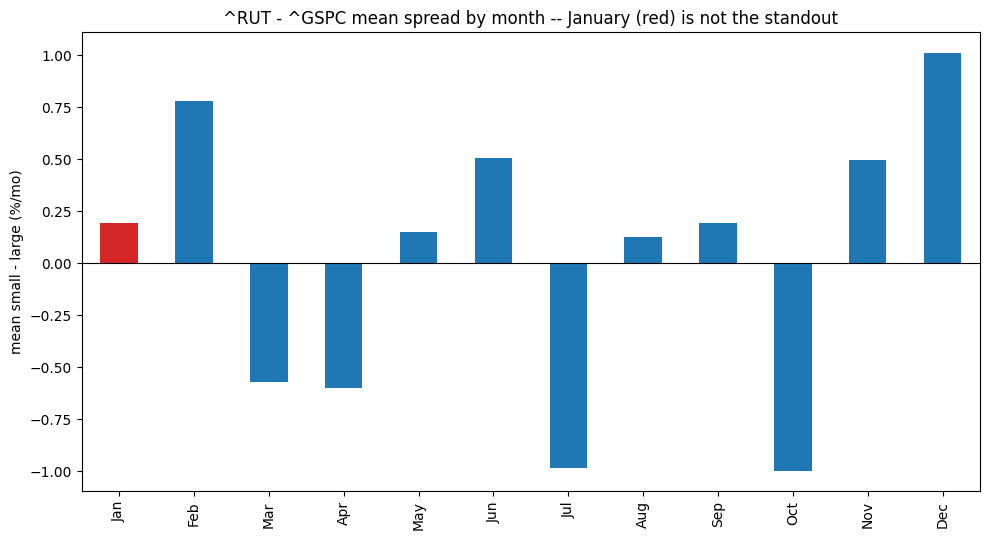

In [3]:
mm = strategy.monthly_means(long)
colors = ['C3' if m == 'Jan' else 'C0' for m in mm.index]
ax = mm.mul(100).plot.bar(color=colors, legend=False)
ax.axhline(0, color='k', lw=.8); ax.set_ylabel('mean small - large (%/mo)')
ax.set_title('^RUT - ^GSPC mean spread by month -- January (red) is not the standout')
plt.tight_layout(); plt.show()

**The decay test** — pre vs post-2000 January spread, and why it has no power:

In [4]:
sub = strategy.subperiod_january(long, split_year=2000)
print(f"Jan spread pre-2000  ({sub['early_n']:2d} Jans): {sub['early_mean']*100:+.2f}%/mo")
print(f"Jan spread 2000+     ({sub['late_n']:2d} Jans): {sub['late_mean']*100:+.2f}%/mo")
print(f"difference (early-late) = {sub['diff']*100:+.2f} pts   Welch t = {sub['t_diff']:+.2f}")
print('=> Yahoo ^RUT starts 1990; the strong 1970s era is OUTSIDE the data, so this contrast is powerless.')

Jan spread pre-2000  ( 9 Jans): +0.03%/mo
Jan spread 2000+     (27 Jans): +0.25%/mo
difference (early-late) = -0.22 pts   Welch t = -0.13
=> Yahoo ^RUT starts 1990; the strong 1970s era is OUTSIDE the data, so this contrast is powerless.


> 💡 **In plain words:** to *measure* a decay you need the before. Our 'before' is only 9 Januaries from the already-quiet 1990s, so the test can't see anything — and the point estimate is even slightly *higher* after 2000. We report `NOT SUPPORTED`, not 'decayed'.

**Tradability** — the seasonal timer vs buy-and-hold of each leg (net 10 bps/switch):

In [5]:
out = []
for lab, fr in [('^RUT/^GSPC', long), ('IWM/SPY', trad)]:
    t = strategy.seasonal_timer(fr, cost_bps=10.0)
    for arm, d in [('timer (small-Jan)', t['timer']), ('large B&H', t['large_bh']), ('small B&H', t['small_bh'])]:
        out.append({'pair': lab, 'arm': arm, 'CAGR %': d['cagr']*100, 'Sharpe': d['sharpe'], 'MaxDD %': d['max_dd']*100})
pd.DataFrame(out).set_index(['pair', 'arm']).round(3)

CAGR %  Sharpe  MaxDD %
pair       arm                                       
^RUT/^GSPC timer (small-Jan)   8.930   0.640  -54.496
           large B&H           9.018   0.662  -52.556
           small B&H           8.449   0.517  -54.081
IWM/SPY    timer (small-Jan)   8.383   0.593  -52.025
           large B&H           8.535   0.619  -50.785
           small B&H           8.600   0.514  -52.473

> 💡 **In plain words:** the timer never beats just holding the large-cap index. Its only edge over small-cap buy-and-hold is lower-vol large-cap exposure 11 months a year — beta, not a January seasonal.

## 5 · The verdict

Signal `NONE` (contrast +0.18 pts, HAC *t* +0.31; hit-rate 44%, Wilson [30%, 60%]), Tradability `MIRAGE` (timer 8.93%/yr < 9.02% large-cap B&H), Decayed-since-1983? `NOT SUPPORTED` (Welch *t* -0.13 on a powerless 9-vs-27 split). The famous anomaly is statistically absent on every tape Yahoo provides.

## 6 · Could you trade it?

Nothing to size. The seasonal tilt loses to the large-cap index before tax and friction, and the original effect's home — illiquid micro-caps with heavy December tax-loss selling — is exactly what a tradable small-cap index averages away. The corner where the edge once lived is the corner you can't cheaply hold.

## 7 · Going further

- **Turn-of-the-year window:** Keim found the effect concentrated in the first ~5 trading days — test a daily Dec-last/Jan-first window.
- **Pre-1990 CRSP:** rerun the decay test with the strong era in-sample for real power.
- **Micro-cap basket:** does the tax-loss story survive on the smallest decile rather than the Russell 2000?